# Untuned CNN

## Data loading

In [6]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import EfficientNetB0
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from transformers import AutoImageProcessor, AutoModelForImageClassification

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

# Path to your dataset (adjust path if needed)
#data_root = "/content/drive/MyDrive/Sampled MRI/"

data_root = "Sampled MRI/"
import os
print(os.listdir(data_root))

['.DS_Store', 'AD', 'NC', 'MCI']


In [8]:
# Paths
groups = {"AD": 0, "MCI": 1, "NC": 2}

images = []
labels = []

# Load images
for group, label in groups.items():
    folder = os.path.join(data_root, group)
    for fname in os.listdir(folder):
        if fname.startswith('.'):   # skip hidden files like .DS_Store
            continue
        if not fname.lower().endswith(".png"):  # skip non-png files
            continue

        img_path = os.path.join(folder, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = img.astype("float32") / 255.0
        images.append(img)
        labels.append(label)

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Add channel dimension for CNN
images = np.expand_dims(images, axis=-1)

# One-hot encode labels
labels_cat = to_categorical(labels, num_classes=3)

## Train, Test, Validation Split

In [ ]:
# Train 70% : test 15% : validation 15%

X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels_cat, test_size=0.15, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765,  # 0.1765 * 85% ≈ 15%
    random_state=42, stratify=y_temp
)

## CNN Model

In [10]:
# Build CNN
input_shape = images.shape[1:]

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train model with explicit validation set
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,771 (42.61 MB)

 Trainable params: 11,168,771 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.3696 - loss: 1.1072 - val_accuracy: 0.4952 - val_loss: 0.9840
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.5458 - loss: 0.9286 - val_accuracy: 0.5996 - val_loss: 0.8333
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6709 - loss: 0.7391 - val_accuracy: 0.6558 - val_loss: 0.7411
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7590 - loss: 0.5779 - val_accuracy: 0.7076 - val_loss: 0.6872
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.8247 - loss: 0.4272 - val_accuracy: 0.7150 - val_loss: 0.6586
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8707 - loss: 0.3346 - val_accuracy: 0.7365 - val_loss: 0.7031
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9044 - loss: 0.2624 - val_accuracy: 0.7506 - val_loss: 0.7226
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9225 - loss: 0.2070 - 

## Evaluation

In [11]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Predictions and metrics
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7860 - loss: 1.1077

Test Accuracy: 0.7785
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Accuracy: 0.7785185185185185

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.72      0.76       450
           1       0.86      0.78      0.82       450
           2       0.70      0.84      0.76       450

    accuracy                           0.78      1350
   macro avg       0.79      0.78      0.78      1350
weighted avg       0.79      0.78      0.78      1350


Confusion Matrix:
 [[323  27 100]
 [ 39 349  62]
 [ 42  29 379]]


## Confusion Matrix

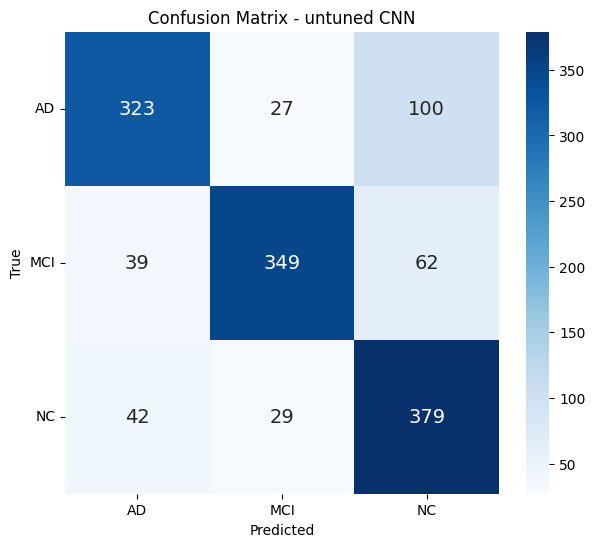

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

classes = ['AD', 'MCI', 'NC']

# confusion matrix - untuned CNN
matrix_data = np.array([
    [323, 27, 100], # True AD
    [39, 349, 62],  # True MCI
    [42, 29, 379]   # True NC
])

df_cm = pd.DataFrame(matrix_data, index=classes, columns=classes)

# Create the plot
plt.figure(figsize=(7, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=True, annot_kws={'size': 14})
plt.title('Confusion Matrix - untuned CNN')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.yticks(rotation=0)
plt.show()